In [36]:
import pandas as pd
import numpy as np

orders = pd.read_csv('../data/processed/orders.csv')

orders.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [37]:
orders['order_date'].dtype

dtype('O')

In [38]:
orders['order_date'] = pd.to_datetime(orders['order_date'])


In [39]:
orders['order_date'].dtype

dtype('<M8[ns]')

In [40]:
orders['month'] = orders['order_date'].dt.to_period('M')

In [41]:
orders[['order_date', 'month']].head(10)

,order_date,month
0,2017-11-08,2017-11
1,2017-11-08,2017-11
2,2017-06-12,2017-06
3,2016-10-11,2016-10
4,2016-10-11,2016-10
5,2015-06-09,2015-06
6,2015-06-09,2015-06
7,2015-06-09,2015-06
8,2015-06-09,2015-06
9,2015-06-09,2015-06


In [42]:
customer_monthly = (orders.groupby(['customer_id', 'month'])['sales'].sum().reset_index())

In [43]:
customer_monthly.head(10)

,customer_id,month,sales
0,AA-10315,2015-03,726.548
1,AA-10315,2015-09,29.500
2,AA-10315,2016-10,26.960
3,AA-10315,2017-03,4406.072
4,AA-10315,2018-06,374.480
5,AA-10375,2015-04,16.520
6,AA-10375,2015-10,34.272
7,AA-10375,2016-02,178.370
8,AA-10375,2016-05,5.248
9,AA-10375,2016-11,84.960


In [44]:
customer_monthly = (orders.groupby(['customer_id', 'month']).agg(total_sales = ('sales', 'sum'),total_profit = ('profit', 'sum')).reset_index())

In [45]:
customer_monthly.head(10)

,customer_id,month,total_sales,total_profit
0,AA-10315,2015-03,726.548,267.4224
1,AA-10315,2015-09,29.500,13.2826
2,AA-10315,2016-10,26.960,7.0096
3,AA-10315,2017-03,4406.072,-747.1021
4,AA-10315,2018-06,374.480,96.5050
5,AA-10375,2015-04,16.520,5.5755
6,AA-10375,2015-10,34.272,11.1384
7,AA-10375,2016-02,178.370,62.0658
8,AA-10375,2016-05,5.248,0.5904
9,AA-10375,2016-11,84.960,6.3720


In [46]:
customer_monthly = (orders.groupby(['customer_id', 'month']).agg(total_sales = ('sales', 'sum'), total_profit = ('profit', 'sum'), total_orders = ('order_id', 'nunique')).reset_index())
customer_monthly.head(10)

,customer_id,month,total_sales,total_profit,total_orders
0,AA-10315,2015-03,726.548,267.4224,1
1,AA-10315,2015-09,29.500,13.2826,1
2,AA-10315,2016-10,26.960,7.0096,1
3,AA-10315,2017-03,4406.072,-747.1021,1
4,AA-10315,2018-06,374.480,96.5050,1
5,AA-10375,2015-04,16.520,5.5755,1
6,AA-10375,2015-10,34.272,11.1384,1
7,AA-10375,2016-02,178.370,62.0658,1
8,AA-10375,2016-05,5.248,0.5904,1
9,AA-10375,2016-11,84.960,6.3720,1


In [47]:
customer_monthly[customer_monthly['total_orders']>1].head(10)

,customer_id,month,total_sales,total_profit,total_orders
33,AB-10060,2018-11,2835.538,441.7752,2
63,AB-10255,2018-06,258.690,107.6623,2
99,AF-10870,2017-05,1591.470,348.2534,2
101,AF-10870,2018-11,280.386,-38.3984,2
116,AG-10330,2018-12,412.152,-66.8801,4
124,AG-10495,2016-10,551.177,-64.6421,3
130,AG-10525,2016-09,701.392,-59.2320,2
136,AG-10675,2018-09,92.480,29.7663,2
142,AG-10900,2016-09,911.179,-25.0458,2
143,AG-10900,2016-12,135.432,43.8728,2


In [48]:
monthly_summary = (orders.groupby(['month']).agg(total_sales = ('sales', 'sum'), total_profit = ('profit', 'sum'),total_orders = ('order_id', 'nunique')).reset_index())
monthly_summary.head(10)

,month,total_sales,total_profit,total_orders
0,2015-01,14236.8950,2450.1907,32
1,2015-02,4519.8920,862.3084,28
2,2015-03,55691.0090,498.7299,71
3,2015-04,28295.3450,3488.8352,66
4,2015-05,23648.2870,2738.7096,69
5,2015-06,34595.1276,4976.5244,66
6,2015-07,33946.3930,-841.4826,65
7,2015-08,27909.4685,5318.1050,72
8,2015-09,81777.3508,8328.0994,130
9,2015-10,31453.3930,3448.2573,78


In [49]:
customer_monthly['profit_margin'] = ((customer_monthly['total_profit']/customer_monthly['total_sales'])*100).round(2)
customer_monthly.head(10)

,customer_id,month,total_sales,total_profit,total_orders,profit_margin
0,AA-10315,2015-03,726.548,267.4224,1,36.81
1,AA-10315,2015-09,29.500,13.2826,1,45.03
2,AA-10315,2016-10,26.960,7.0096,1,26.00
3,AA-10315,2017-03,4406.072,-747.1021,1,-16.96
4,AA-10315,2018-06,374.480,96.5050,1,25.77
5,AA-10375,2015-04,16.520,5.5755,1,33.75
6,AA-10375,2015-10,34.272,11.1384,1,32.50
7,AA-10375,2016-02,178.370,62.0658,1,34.80
8,AA-10375,2016-05,5.248,0.5904,1,11.25
9,AA-10375,2016-11,84.960,6.3720,1,7.50


In [50]:
customer_monthly['avg_order_value'] = (customer_monthly['total_sales']/customer_monthly['total_orders']).round(2)
customer_monthly.head(15)

,customer_id,month,total_sales,total_profit,total_orders,profit_margin,avg_order_value
0,AA-10315,2015-03,726.548,267.4224,1,36.81,726.55
1,AA-10315,2015-09,29.500,13.2826,1,45.03,29.50
2,AA-10315,2016-10,26.960,7.0096,1,26.00,26.96
3,AA-10315,2017-03,4406.072,-747.1021,1,-16.96,4406.07
4,AA-10315,2018-06,374.480,96.5050,1,25.77,374.48
5,AA-10375,2015-04,16.520,5.5755,1,33.75,16.52
6,AA-10375,2015-10,34.272,11.1384,1,32.50,34.27
7,AA-10375,2016-02,178.370,62.0658,1,34.80,178.37
8,AA-10375,2016-05,5.248,0.5904,1,11.25,5.25
9,AA-10375,2016-11,84.960,6.3720,1,7.50,84.96


In [51]:
customer_monthly[customer_monthly['total_orders']>1].head(10)

,customer_id,month,total_sales,total_profit,total_orders,profit_margin,avg_order_value
33,AB-10060,2018-11,2835.538,441.7752,2,15.58,1417.77
63,AB-10255,2018-06,258.690,107.6623,2,41.62,129.34
99,AF-10870,2017-05,1591.470,348.2534,2,21.88,795.74
101,AF-10870,2018-11,280.386,-38.3984,2,-13.69,140.19
116,AG-10330,2018-12,412.152,-66.8801,4,-16.23,103.04
124,AG-10495,2016-10,551.177,-64.6421,3,-11.73,183.73
130,AG-10525,2016-09,701.392,-59.2320,2,-8.44,350.70
136,AG-10675,2018-09,92.480,29.7663,2,32.19,46.24
142,AG-10900,2016-09,911.179,-25.0458,2,-2.75,455.59
143,AG-10900,2016-12,135.432,43.8728,2,32.39,67.72


In [52]:
customer_monthly['total_sales'] = customer_monthly['total_sales'].round(2)
customer_monthly['total_profit'] = customer_monthly['total_profit'].round(2)
customer_monthly.head(10)

,customer_id,month,total_sales,total_profit,total_orders,profit_margin,avg_order_value
0,AA-10315,2015-03,726.55,267.42,1,36.81,726.55
1,AA-10315,2015-09,29.50,13.28,1,45.03,29.50
2,AA-10315,2016-10,26.96,7.01,1,26.00,26.96
3,AA-10315,2017-03,4406.07,-747.10,1,-16.96,4406.07
4,AA-10315,2018-06,374.48,96.50,1,25.77,374.48
5,AA-10375,2015-04,16.52,5.58,1,33.75,16.52
6,AA-10375,2015-10,34.27,11.14,1,32.50,34.27
7,AA-10375,2016-02,178.37,62.07,1,34.80,178.37
8,AA-10375,2016-05,5.25,0.59,1,11.25,5.25
9,AA-10375,2016-11,84.96,6.37,1,7.50,84.96


In [53]:
customer_monthly['total_sales'].agg(['mean', 'var'])

mean    4.973373e+02
var     1.006384e+06
Name: total_sales, dtype: float64

In [54]:
customer_monthly['total_sales'].std()

np.float64(1003.1869960280201)

In [55]:
customer_monthly['total_sales'].median()

np.float64(177.0)

In [56]:
customer_monthly['total_sales'].quantile([0.25, 0.75, 1])

0.25       42.835
0.75      564.160
1.00    23661.230
Name: total_sales, dtype: float64

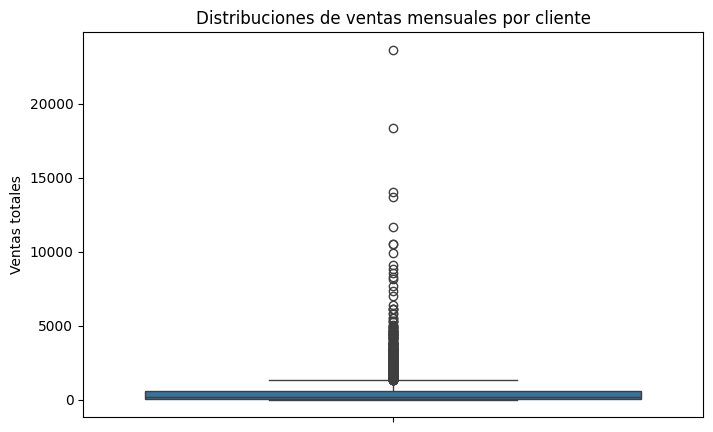

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize= (8,5))

sns.boxplot( data = customer_monthly,
            y='total_sales')

plt.title( 'Distribuciones de ventas mensuales por cliente')
plt.ylabel('Ventas totales')
plt.show()

In [61]:
q1 = customer_monthly['total_sales'].quantile(0.25)
print(q1)
q3 = customer_monthly['total_sales'].quantile(0.75)
print(q3)
iqr = q3- q1
upper_limit = q3 + 1.5*iqr
upper_limit

42.834999999999994
564.1600000000001


np.float64(1346.1475)

In [62]:
lower_limit = q1 - 1.5*iqr
lower_limit

np.float64(-739.1525)

In [63]:
customer_segments = orders[['customer_id', 'segment']].drop_duplicates()

customer_monthly = customer_monthly.merge(customer_segments, on ='customer_id', how='left')

In [65]:
orders['segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [66]:
orders.groupby('customer_id')['segment'].nunique().sort_values(ascending=False).head(10)

customer_id
AA-10315    1
AA-10375    1
AA-10480    1
AA-10645    1
AB-10015    1
AB-10060    1
AB-10105    1
AB-10150    1
AB-10165    1
AB-10255    1
Name: segment, dtype: int64

In [67]:
sales_consumer = customer_monthly.loc[customer_monthly['segment'] == 'Consumer','total_sales']
sales_corporate = customer_monthly.loc[customer_monthly['segment'] == 'Corporate', 'total_sales']

In [69]:
print('Consumer:', len(sales_consumer))
print('Corporate:', len(sales_corporate))

Consumer: 2395
Corporate: 1394


In [70]:
alpha = 0.05

from scipy.stats import ttest_ind

t_stat,p_value = ttest_ind(sales_consumer,sales_corporate, equal_var= False)
print('t_statistic:', t_stat)
print('p_value:', p_value)

t_statistic: -0.6733754704838981
p_value: 0.5007620565712653


Durante este análisis se trabajó con agregaciones temporales para estudiar las ventas
mensuales por cliente y se calcularon métricas de negocio como el margen de beneficio
y el valor promedio por orden.

También se utilizaron estadísticas descriptivas como la media, mediana, varianza,
desviación estándar, cuantiles e IQR para comprender la distribución de las ventas
y detectar posibles valores atípicos.

Finalmente, se compararon las ventas mensuales de los segmentos Consumer y Corporate
mediante una prueba t para muestras independientes.

Con un nivel de significancia de 0.05 se obtuvo un p-value aproximado de 0.501.
Como el p-value es mayor que alpha, no rechazamos la hipótesis nula.

Por lo tanto, con estos datos no existe evidencia estadística suficiente para afirmar
que las ventas mensuales promedio de Consumer y Corporate sean diferentes.